# Configurable MLP

## For fetus dataset

In [93]:
# Import libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

In [94]:
# Make a configuration table
CONFIG = {
	# Device
	'device': 'cuda' if torch.cuda.is_available() else 'cpu',

	# Data
	'test_size': 0.3,
	'random_state': 42,

	# Architecture
	'input_size': 16,
	'hidden_layers': [10, 5], # List of hidden layer sizes (flexible depth) - reduced to prevent overfitting
	'activation': 'gelu', # 'relu', 'sigmoid', 'tanh', 'leaky_relu', 'elu', 'gelu'
	'output_activation': 'sigmoid', # 'softmax', 'sigmoid', 'tanh'
	
	# Training
	'epochs': 300,
	'batch_size': 32, # Smaller batch size for better regularization
	'learning_rate': 0.001, # Lower learning rate for more stable training
	'optimizer': 'adam',

	# Loss function
	'loss_function': 'cross_entropy', # 'cross_entropy', 'nll', 'bce

	# Regularization - increased to reduce overfitting
	'weight_decay': 0.001, # Increased L2 regularization
	'dropout_rate': 0.4, # Increased dropout probability
	'use_batch_norm': True, # Batch normalization after each hidden layer

	# Learning rate scheduler
	'use_lr_scheduler': True,
	'lr_scheduler_factor': 0.15,
	'lr_scheduler_patience': 20, 

	# Early stopping
	'patience': 30, # Number of epochs to wait for improvement
	'min_delta': 0.0001 # Minimum change to qualify as improvement
}

In [95]:
# Load train and test datasets separately
df_train = pd.read_csv('fetus_trainingdata.csv')
df_test = pd.read_csv('fetus_testingdata.csv')

features = df_train.columns[1:]
target = df_train.columns[0]

# Extract features and targets from both datasets
X_train = df_train[features].values
y_train = df_train[target].values
X_test = df_test[features].values
y_test = df_test[target].values

# Map labels - use combined unique labels to ensure consistent mapping
all_y = np.concatenate([y_train, y_test])
unique_y = np.unique(all_y)
num_classes = len(unique_y)
label_map = {val: i for i, val in enumerate(unique_y)}
y_train = np.array([label_map[val] for val in y_train])
y_test = np.array([label_map[val] for val in y_test])

# Scale - fit on training data only, then transform both
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [96]:
# Dataset class
class FetusDataset(Dataset):
	def __init__(self, X, y):
		self.X = torch.tensor(X, dtype = torch.float32)
		dtype_y = torch.float32 if CONFIG['loss_function'] == 'bce' else torch.long
		self.y = torch.tensor(y, dtype = dtype_y)

	def __len__(self):
		return len(self.y)

	def __getitem__(self, idx):
		return self.X[idx], self.y[idx]

In [97]:
# Flexible MLP Model
class ConfigurableMLP(nn.Module):
	def __init__(self, config, output_size):
		super(ConfigurableMLP, self).__init__()

		# Activation function
		activation_map = {
			'relu': nn.ReLU(),
			'sigmoid': nn.Sigmoid(),
			'tanh': nn.Tanh(),
			'leaky_relu': nn.LeakyReLU(0.01),
			'elu': nn.ELU(),
			'gelu': nn.GELU()
		}

		self.activation = activation_map[config['activation']]

		# Build layers dynamically
		layers = []
		prev_size = config['input_size']

		for hidden_size in config['hidden_layers']:
			layers.append(nn.Linear(prev_size, hidden_size))

			if config['use_batch_norm']:
				layers.append(nn.BatchNorm1d(hidden_size))

			layers.append(activation_map[config['activation']])

			if config['dropout_rate'] > 0:
				layers.append(nn.Dropout(config['dropout_rate']))

			prev_size = hidden_size
		
		# Output layer
		layers.append(nn.Linear(prev_size, output_size))

		# Output activation function
		if config['output_activation'] == 'softmax':
			layers.append(nn.Softmax(dim=1))
		elif config['output_activation'] == 'sigmoid':
			layers.append(nn.Sigmoid())
		elif config['output_activation'] == 'tanh':
			layers.append(nn.Tanh())

		self.network = nn.Sequential(*layers)

	def forward(self, x):
		return self.network(x)

In [98]:
# Create datasets and loaders
train_dataset = FetusDataset(X_train_scaled, y_train)
test_dataset = FetusDataset(X_test_scaled, y_test)
train_loader = DataLoader(train_dataset, batch_size = CONFIG['batch_size'], shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = CONFIG['batch_size'], shuffle = False)

# Determine output size based on loss function
if CONFIG['loss_function'] == 'bce':
	if num_classes != 2:
		raise ValueError("BCE loss is only suitable for binary classification (2 classes).")
	output_size = 1
	CONFIG['output_activation'] = 'none'  # No activation for BCEWithLogitsLoss
else:
	output_size = num_classes

# Init model
device = torch.device(CONFIG['device'])
model = ConfigurableMLP(CONFIG, output_size).to(device)

# Loss function
if CONFIG['loss_function'] == 'cross_entropy':
	criterion = nn.CrossEntropyLoss()
elif CONFIG['loss_function'] == 'nll':
	criterion = nn.NLLLoss()
elif CONFIG['loss_function'] == 'bce':
	criterion = nn.BCEWithLogitsLoss()

# Optimizer
if CONFIG['optimizer'] == 'adam':
	optimizer = optim.Adam(model.parameters(), lr = CONFIG['learning_rate'], weight_decay = CONFIG['weight_decay'])

# Learning rate scheduler
if CONFIG['use_lr_scheduler']:
	scheduler = optim.lr_scheduler.ReduceLROnPlateau(
		optimizer, mode = 'min', factor = CONFIG['lr_scheduler_factor'],
		patience = CONFIG['lr_scheduler_patience']
	)

# Training loop
train_losses, test_losses = [], []
train_accs, test_accs = [], []
best_test_loss = float('inf')
patience_counter = 0

for epoch in range(CONFIG['epochs']):
	# Train
	model.train()
	running_loss = 0.0
	correct = 0
	total = 0

	for inputs, labels in train_loader:
		inputs = inputs.to(device)
		labels = labels.to(device)
		optimizer.zero_grad()
		outputs = model(inputs)
		if CONFIG['loss_function'] == 'bce':
			labels_for_loss = labels.unsqueeze(1)
		else:
			labels_for_loss = labels
		loss = criterion(outputs, labels_for_loss)
		loss.backward()
		torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm = 1.0) # Gradient clipping
		optimizer.step()

		running_loss += loss.item()
		if CONFIG['loss_function'] == 'bce':
			predicted = (outputs > 0).float().squeeze()
			correct += (predicted == labels).sum().item()
		else:
			_, predicted = torch.max(outputs.data, 1)
			correct += (predicted == labels).sum().item()
		total += labels.size(0)

	train_losses.append(running_loss / len(train_loader))
	train_accs.append(correct / total)

	# Test
	model.eval()
	test_loss = 0.0
	correct = 0
	total = 0

	with torch.no_grad():
		for inputs, labels in test_loader:
			inputs = inputs.to(device)
			labels = labels.to(device)
			outputs = model(inputs)
			if CONFIG['loss_function'] == 'bce':
				labels_for_loss = labels.unsqueeze(1)
			else:
				labels_for_loss = labels
			loss = criterion(outputs, labels_for_loss)
			test_loss += loss.item()
			if CONFIG['loss_function'] == 'bce':
				predicted = (outputs > 0).float().squeeze()
				correct += (predicted == labels).sum().item()
			else:
				_, predicted = torch.max(outputs.data, 1)
				correct += (predicted == labels).sum().item()
			total += labels.size(0)

	test_losses.append(test_loss / len(test_loader))
	test_accs.append(correct / total)

	# Learning rate scheduler step
	if CONFIG['use_lr_scheduler']:
		scheduler.step(test_losses[-1])

	if (epoch + 1) % 20 == 0:
		current_lr = optimizer.param_groups[0]['lr']
		print(f"Epoch {epoch+1}/{CONFIG['epochs']}: "
			f"Train Loss: {train_losses[-1]:.4f}, Train Acc: {train_accs[-1]:.4f}, "
			f"Test Loss: {test_losses[-1]:.4f}, Test Acc: {test_accs[-1]:.4f}, "
			f"LR: {current_lr:.6f}")

	# Early stopping check
	current_test_loss = test_losses[-1]
	if current_test_loss < best_test_loss - CONFIG['min_delta']:
		best_test_loss = current_test_loss
		patience_counter = 0
	else:
		patience_counter += 1
		if patience_counter >= CONFIG['patience']:
			print(f"Early stopping triggered after {epoch + 1} epochs")
			break

Epoch 20/300: Train Loss: 0.6878, Train Acc: 0.5549, Test Loss: 0.6676, Test Acc: 0.6897, LR: 0.001000
Epoch 40/300: Train Loss: 0.6528, Train Acc: 0.6329, Test Loss: 0.6386, Test Acc: 0.6724, LR: 0.001000
Epoch 60/300: Train Loss: 0.6412, Train Acc: 0.7110, Test Loss: 0.6132, Test Acc: 0.6897, LR: 0.001000
Epoch 80/300: Train Loss: 0.6210, Train Acc: 0.6821, Test Loss: 0.6001, Test Acc: 0.7414, LR: 0.001000
Epoch 100/300: Train Loss: 0.6035, Train Acc: 0.7081, Test Loss: 0.5958, Test Acc: 0.7414, LR: 0.001000
Early stopping triggered after 118 epochs


### Overfitting Analysis

In [99]:
# Simplified overfitting analysis
def analyze_overfitting(train_losses, test_losses, train_accs, test_accs):
	"""
	Simple overfitting analysis comparing train vs test performance.
	"""
	
	final_train_loss = train_losses[-1]
	final_test_loss = test_losses[-1]
	final_train_acc = train_accs[-1]
	final_test_acc = test_accs[-1]
	
	# Calculate gaps (test - train)
	loss_gap = final_test_loss - final_train_loss  # Should be ≤ 0.05
	acc_gap = final_train_acc - final_test_acc  # Should be ≤ 0.10 (train_acc - test_acc)
	
	# Check if test loss is increasing while train loss decreases (divergence)
	is_diverging = False
	if len(train_losses) > 10:
		recent_train_trend = np.mean(train_losses[-10:]) - np.mean(train_losses[-20:-10]) if len(train_losses) > 20 else 0
		recent_test_trend = np.mean(test_losses[-10:]) - np.mean(test_losses[-20:-10]) if len(test_losses) > 20 else 0
		is_diverging = recent_train_trend < 0 and recent_test_trend > 0
	
	# Assessment
	print("="*50)
	print("OVERFITTING ANALYSIS")
	print("="*50)
	print(f"Train Loss: {final_train_loss:.4f} | Test Loss: {final_test_loss:.4f} | Gap (test-train): {loss_gap:.4f}")
	print(f"Train Acc:  {final_train_acc:.4f}  | Test Acc:  {final_test_acc:.4f}  | Gap (train-test): {acc_gap:.4f}")
	
	loss_requirement_met = loss_gap <= 0.05
	acc_requirement_met = acc_gap <= 0.10
	
	print(f"\nRequirements Check:")
	print(f"  Test Loss - Train Loss ≤ 0.05: {loss_gap:.4f} {'✓' if loss_requirement_met else '✗'}")
	print(f"  Train Acc - Test Acc ≤ 0.10: {acc_gap:.4f} {'✓' if acc_requirement_met else '✗'}")
	
	if is_diverging:
		print("\nOVERFITTING: Test loss increasing while train loss decreasing")
	elif loss_gap > 0.1 or acc_gap > 0.1:
		print("\nOVERFITTING: Large gap between train and test performance")
	else:
		print("\nNo significant overfitting detected")
	
	return {
		'loss_gap': loss_gap,
		'acc_gap': acc_gap,
		'is_diverging': is_diverging,
		'loss_requirement_met': loss_requirement_met,
		'acc_requirement_met': acc_requirement_met
	}

# Analyze the current model
analysis = analyze_overfitting(train_losses, test_losses, train_accs, test_accs)


OVERFITTING ANALYSIS
Train Loss: 0.6025 | Test Loss: 0.5960 | Gap (test-train): -0.0065
Train Acc:  0.6879  | Test Acc:  0.7069  | Gap (train-test): -0.0190

Requirements Check:
  Test Loss - Train Loss ≤ 0.05: -0.0065 ✓
  Train Acc - Test Acc ≤ 0.10: -0.0190 ✓

OVERFITTING: Test loss increasing while train loss decreasing


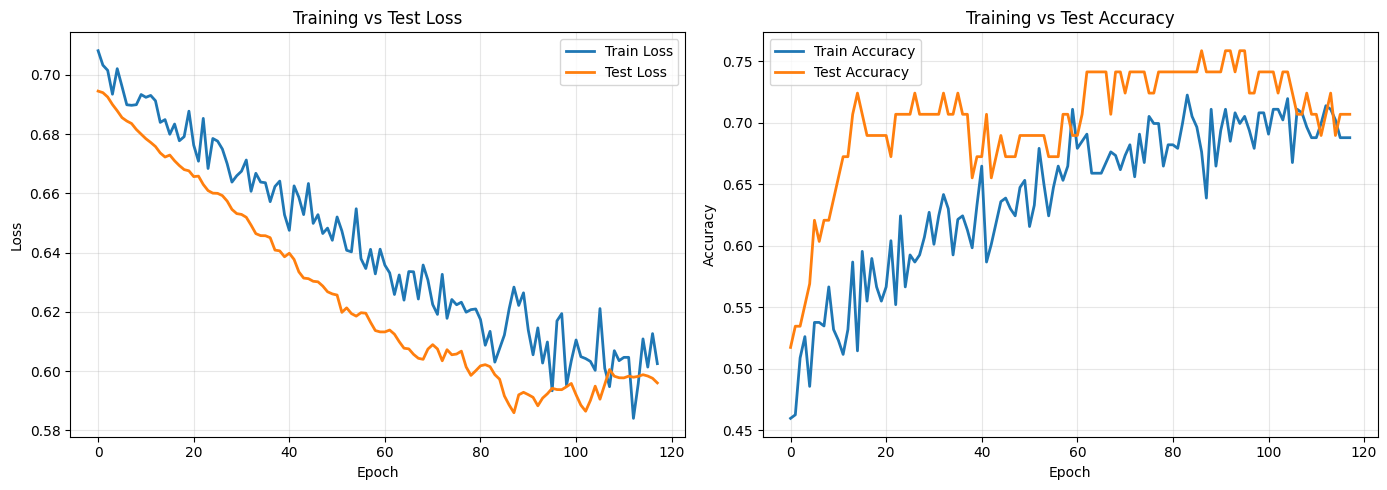


FINAL RESULTS
Architecture: 16 -> 10 -> 5 -> 2
Activation: gelu
Optimizer: adam (LR: 0.001, Weight Decay: 0.001)
Dropout: 0.4, Batch Norm: True

Final Train Accuracy: 0.6879
Final Test Accuracy: 0.7069
Final Train Loss: 0.6025
Final Test Loss: 0.5960


In [100]:
# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
ax1.plot(train_losses, label = 'Train Loss', linewidth = 2)
ax1.plot(test_losses, label = 'Test Loss', linewidth = 2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training vs Test Loss')
ax1.legend()
ax1.grid(True, alpha = 0.3)

# Accuracy plot
ax2.plot(train_accs, label = 'Train Accuracy', linewidth = 2)
ax2.plot(test_accs, label = 'Test Accuracy', linewidth = 2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training vs Test Accuracy')
ax2.legend()
ax2.grid(True, alpha = 0.3)

plt.tight_layout()
plt.show()

# Results summary table
print("\n" + "="*60)
print("FINAL RESULTS")
print("="*60)
print(f"Architecture: {CONFIG['input_size']} -> {' -> '.join(map(str, CONFIG['hidden_layers']))} -> {output_size}")
print(f"Activation: {CONFIG['activation']}")
print(f"Optimizer: {CONFIG['optimizer']} (LR: {CONFIG['learning_rate']}, Weight Decay: {CONFIG['weight_decay']})")
print(f"Dropout: {CONFIG['dropout_rate']}, Batch Norm: {CONFIG['use_batch_norm']}")
print(f"\nFinal Train Accuracy: {train_accs[-1]:.4f}")
print(f"Final Test Accuracy: {test_accs[-1]:.4f}")
print(f"Final Train Loss: {train_losses[-1]:.4f}")
print(f"Final Test Loss: {test_losses[-1]:.4f}")

## For diabetes dataset (AI-generated for reference)

In [101]:
# Configuration for diabetes dataset
CONFIG_DIAB = {
	# Device
	'device': 'cuda' if torch.cuda.is_available() else 'cpu',

	# Data
	'test_size': 0.3,
	'random_state': 42,

	# Architecture (input_size will be set after loading data)
	'input_size': 0,
	'hidden_layers': [16, 8],
	'activation': 'gelu',
	'output_activation': 'none',
	
	# Training
	'epochs': 200,
	'batch_size': 32,
	'learning_rate': 0.001,
	'optimizer': 'adam',

	# Loss function
	'loss_function': 'cross_entropy',

	# Regularization
	'weight_decay': 0.001,
	'dropout_rate': 0.3,
	'use_batch_norm': True,

	# Learning rate scheduler
	'use_lr_scheduler': True,
	'lr_scheduler_factor': 0.2,
	'lr_scheduler_patience': 15,

	# Early stopping
	'patience': 20,
	'min_delta': 0.0001
}


In [102]:
# Load diabetes dataset
import os

diab_path = 'diabetes_data.csv'
if not os.path.exists(diab_path):
	raise FileNotFoundError(f"File not found: {diab_path}")

df_diab = pd.read_csv(diab_path, sep=';')

# Encode categorical columns
if 'gender' in df_diab.columns:
	gender_map = {'Male': 1, 'Female': 0}
	df_diab['gender'] = df_diab['gender'].map(gender_map).astype(int)

# Define target and features
target_diab = 'class'
features_diab = [c for c in df_diab.columns if c != target_diab]

# Ensure all features are numeric
for col in features_diab:
	if df_diab[col].dtype == 'object':
		df_diab[col] = pd.to_numeric(df_diab[col], errors='coerce')

# Drop rows with any missing values after coercion
df_diab = df_diab.dropna().reset_index(drop=True)

X_diab = df_diab[features_diab].values
y_diab = df_diab[target_diab].values

# Map labels to {0,1}
unique_y_diab = np.unique(y_diab)
num_classes_diab = len(unique_y_diab)
label_map_diab = {val: i for i, val in enumerate(unique_y_diab)}
y_diab = np.array([label_map_diab[val] for val in y_diab])

# Update diabetes input size from data
CONFIG_DIAB['input_size'] = X_diab.shape[1]

# Check if stratification is possible (each class needs at least 2 samples)
class_counts_diab = np.bincount(y_diab)
can_stratify_diab = np.all(class_counts_diab >= 2)

# Split and scale
if can_stratify_diab:
	X_train_diab, X_test_diab, y_train_diab, y_test_diab = train_test_split(
		X_diab, y_diab, test_size = CONFIG_DIAB['test_size'],
		random_state = CONFIG_DIAB['random_state'],
		stratify = y_diab
	)
else:
	print(f"Warning: Cannot stratify diabetes data - some classes have fewer than 2 samples. Class counts: {dict(zip(unique_y_diab, class_counts_diab))}")
	X_train_diab, X_test_diab, y_train_diab, y_test_diab = train_test_split(
		X_diab, y_diab, test_size = CONFIG_DIAB['test_size'],
		random_state = CONFIG_DIAB['random_state']
	)

scaler_diab = StandardScaler()
X_train_diab_scaled = scaler_diab.fit_transform(X_train_diab)
X_test_diab_scaled = scaler_diab.transform(X_test_diab)


In [103]:
# Diabetes dataset class
class DiabetesDataset(Dataset):
	def __init__(self, X, y):
		self.X = torch.tensor(X, dtype = torch.float32)
		self.y = torch.tensor(y, dtype = torch.long)

	def __len__(self):
		return len(self.y)

	def __getitem__(self, idx):
		return self.X[idx], self.y[idx]


In [104]:
# Create datasets, model, and training loop for diabetes
train_dataset_diab = DiabetesDataset(X_train_diab_scaled, y_train_diab)
test_dataset_diab = DiabetesDataset(X_test_diab_scaled, y_test_diab)
train_loader_diab = DataLoader(train_dataset_diab, batch_size = CONFIG_DIAB['batch_size'], shuffle = True)
test_loader_diab = DataLoader(test_dataset_diab, batch_size = CONFIG_DIAB['batch_size'], shuffle = False)

# Determine output size
output_size_diab = num_classes_diab if CONFIG_DIAB['loss_function'] != 'bce' else 1

# Init model
device_diab = torch.device(CONFIG_DIAB['device'])
model_diab = ConfigurableMLP(CONFIG_DIAB, output_size_diab).to(device_diab)

# Loss function
if CONFIG_DIAB['loss_function'] == 'cross_entropy':
	criterion_diab = nn.CrossEntropyLoss()
elif CONFIG_DIAB['loss_function'] == 'nll':
	criterion_diab = nn.NLLLoss()
elif CONFIG_DIAB['loss_function'] == 'bce':
	criterion_diab = nn.BCEWithLogitsLoss()

# Optimizer
if CONFIG_DIAB['optimizer'] == 'adam':
	optimizer_diab = optim.Adam(model_diab.parameters(), lr = CONFIG_DIAB['learning_rate'], weight_decay = CONFIG_DIAB['weight_decay'])

# Learning rate scheduler
if CONFIG_DIAB['use_lr_scheduler']:
	scheduler_diab = optim.lr_scheduler.ReduceLROnPlateau(
		optimizer_diab, mode = 'min', factor = CONFIG_DIAB['lr_scheduler_factor'],
		patience = CONFIG_DIAB['lr_scheduler_patience']
	)

# Training loop
diab_train_losses, diab_test_losses = [], []
diab_train_accs, diab_test_accs = [], []
best_test_loss_diab = float('inf')
patience_counter_diab = 0

for epoch in range(CONFIG_DIAB['epochs']):
	# Train
	model_diab.train()
	running_loss = 0.0
	correct = 0
	total = 0

	for inputs, labels in train_loader_diab:
		inputs = inputs.to(device_diab)
		labels = labels.to(device_diab)
		optimizer_diab.zero_grad()
		outputs = model_diab(inputs)
		if CONFIG_DIAB['loss_function'] == 'bce':
			labels_for_loss = labels.unsqueeze(1).float()
		else:
			labels_for_loss = labels
		loss = criterion_diab(outputs, labels_for_loss)
		loss.backward()
		torch.nn.utils.clip_grad_norm_(model_diab.parameters(), max_norm = 1.0)
		optimizer_diab.step()

		running_loss += loss.item()
		if CONFIG_DIAB['loss_function'] == 'bce':
			predicted = (outputs > 0).float().squeeze()
			correct += (predicted == labels.float()).sum().item()
		else:
			_, predicted = torch.max(outputs.data, 1)
			correct += (predicted == labels).sum().item()
		total += labels.size(0)

	diab_train_losses.append(running_loss / len(train_loader_diab))
	diab_train_accs.append(correct / total)

	# Test
	model_diab.eval()
	test_loss = 0.0
	correct = 0
	total = 0

	with torch.no_grad():
		for inputs, labels in test_loader_diab:
			inputs = inputs.to(device_diab)
			labels = labels.to(device_diab)
			outputs = model_diab(inputs)
			if CONFIG_DIAB['loss_function'] == 'bce':
				labels_for_loss = labels.unsqueeze(1).float()
			else:
				labels_for_loss = labels
			loss = criterion_diab(outputs, labels_for_loss)
			test_loss += loss.item()
			if CONFIG_DIAB['loss_function'] == 'bce':
				predicted = (outputs > 0).float().squeeze()
				correct += (predicted == labels.float()).sum().item()
			else:
				_, predicted = torch.max(outputs.data, 1)
				correct += (predicted == labels).sum().item()
			total += labels.size(0)

	diab_test_losses.append(test_loss / len(test_loader_diab))
	diab_test_accs.append(correct / total)

	# Scheduler
	if CONFIG_DIAB['use_lr_scheduler']:
		scheduler_diab.step(diab_test_losses[-1])

	# Early stopping
	current_test_loss = diab_test_losses[-1]
	if current_test_loss < best_test_loss_diab - CONFIG_DIAB['min_delta']:
		best_test_loss_diab = current_test_loss
		patience_counter_diab = 0
	else:
		patience_counter_diab += 1
		if patience_counter_diab >= CONFIG_DIAB['patience']:
			print(f"[Diabetes] Early stopping at epoch {epoch + 1}")
			break

	if (epoch + 1) % 20 == 0:
		current_lr = optimizer_diab.param_groups[0]['lr']
		print(f"[Diabetes] Epoch {epoch+1}/{CONFIG_DIAB['epochs']}: Train Loss {diab_train_losses[-1]:.4f}, Train Acc {diab_train_accs[-1]:.4f}, Test Loss {diab_test_losses[-1]:.4f}, Test Acc {diab_test_accs[-1]:.4f}, LR {current_lr:.6f}")


[Diabetes] Epoch 20/200: Train Loss 0.3343, Train Acc 0.8764, Test Loss 0.2576, Test Acc 0.9423, LR 0.001000
[Diabetes] Epoch 40/200: Train Loss 0.2128, Train Acc 0.9286, Test Loss 0.1600, Test Acc 0.9423, LR 0.001000
[Diabetes] Epoch 60/200: Train Loss 0.1846, Train Acc 0.9148, Test Loss 0.1275, Test Acc 0.9615, LR 0.001000
[Diabetes] Epoch 80/200: Train Loss 0.1559, Train Acc 0.9423, Test Loss 0.1045, Test Acc 0.9615, LR 0.001000
[Diabetes] Epoch 100/200: Train Loss 0.1380, Train Acc 0.9451, Test Loss 0.0985, Test Acc 0.9615, LR 0.001000
[Diabetes] Epoch 120/200: Train Loss 0.1064, Train Acc 0.9698, Test Loss 0.0949, Test Acc 0.9551, LR 0.001000
[Diabetes] Epoch 140/200: Train Loss 0.1110, Train Acc 0.9643, Test Loss 0.0884, Test Acc 0.9551, LR 0.001000
[Diabetes] Early stopping at epoch 150


In [105]:
# Analyze diabetes model using existing analysis function
analysis_diab = analyze_overfitting(diab_train_losses, diab_test_losses, diab_train_accs, diab_test_accs)

# Basic results summary for diabetes
print("\n" + "="*60)
print("DIABETES FINAL RESULTS")
print("="*60)
print(f"Architecture: {CONFIG_DIAB['input_size']} -> {' -> '.join(map(str, CONFIG_DIAB['hidden_layers']))} -> {output_size_diab}")
print(f"Activation: {CONFIG_DIAB['activation']}")
print(f"Optimizer: {CONFIG_DIAB['optimizer']} (LR: {CONFIG_DIAB['learning_rate']}, Weight Decay: {CONFIG_DIAB['weight_decay']})")
print(f"Dropout: {CONFIG_DIAB['dropout_rate']}, Batch Norm: {CONFIG_DIAB['use_batch_norm']}")
print(f"\nFinal Train Accuracy: {diab_train_accs[-1]:.4f}")
print(f"Final Test Accuracy: {diab_test_accs[-1]:.4f}")
print(f"Final Train Loss: {diab_train_losses[-1]:.4f}")
print(f"Final Test Loss: {diab_test_losses[-1]:.4f}")


OVERFITTING ANALYSIS
Train Loss: 0.0813 | Test Loss: 0.0859 | Gap (test-train): 0.0046
Train Acc:  0.9780  | Test Acc:  0.9487  | Gap (train-test): 0.0293

Requirements Check:
  Test Loss - Train Loss ≤ 0.05: 0.0046 ✓
  Train Acc - Test Acc ≤ 0.10: 0.0293 ✓

OVERFITTING: Test loss increasing while train loss decreasing

DIABETES FINAL RESULTS
Architecture: 16 -> 16 -> 8 -> 2
Activation: gelu
Optimizer: adam (LR: 0.001, Weight Decay: 0.001)
Dropout: 0.3, Batch Norm: True

Final Train Accuracy: 0.9780
Final Test Accuracy: 0.9487
Final Train Loss: 0.0813
Final Test Loss: 0.0859


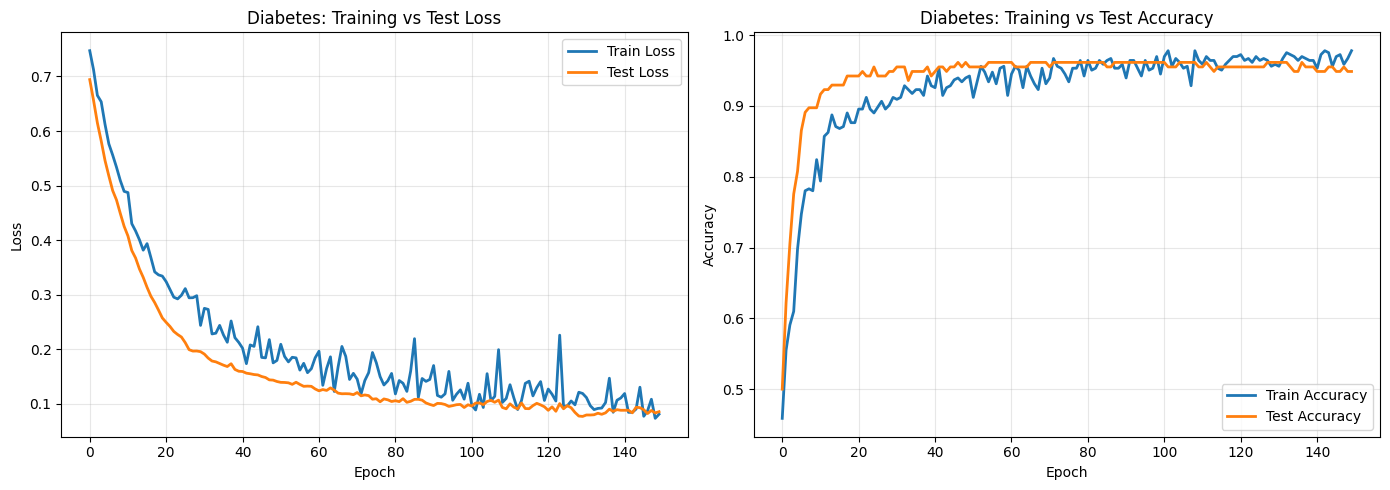

In [106]:
# Visualization for diabetes dataset
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
ax1.plot(diab_train_losses, label = 'Train Loss', linewidth = 2)
ax1.plot(diab_test_losses, label = 'Test Loss', linewidth = 2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Diabetes: Training vs Test Loss')
ax1.legend()
ax1.grid(True, alpha = 0.3)

# Accuracy plot
ax2.plot(diab_train_accs, label = 'Train Accuracy', linewidth = 2)
ax2.plot(diab_test_accs, label = 'Test Accuracy', linewidth = 2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Diabetes: Training vs Test Accuracy')
ax2.legend()
ax2.grid(True, alpha = 0.3)

plt.tight_layout()
plt.show()
